# 01 - Data Curation
Download and explore PHI-base data, filter and clean sequences, export processed dataset.

## GoHREP:

**Goal:**

Curate a clean, balanced, and non-redundant dataset of pathogen effector sequences from PHI-base, mapped to five distinct virulence categories, and formatted for ESM-2 fine-tuning.

**Hypothesis:**

Systematically filtering biological noise and reducing sequence redundancy in the PHI-base dataset will prevent model memorisation and enably the ESM-2 model to learn generalisable sequence features associated with the five virulence classes.

**Rationale:**

High-quality input data is necessary for effective parameter-efficient fine-tuning. Removing fragments, pseudogenes, and highly redundant sequences ensures the model learns biological signals rather than dataset artifacts. Stratified splitting is required to handle the inherent class imbalances present in biological databases.

**Experimental Plan:**

1. Source acquisition: Download the most recent PHI-base metadata file and the corresponding sequence FASTA files.
2. Parsing and target mapping: Merge the sequence data with the metadata. Map the raw PHI-base mutant phenotypes to the 5 target virulence categories.
3. Biological quality control: Filter sequences by length, remove sequences exceeding an acceptable threshold of ambiguous residues, and filter out unusual amino acid compositions (e.g. extreme poly-X runs).
4. Redundancy reduction: Cluster the filtered sequences using CD-HIT or MMseqs2 at a 90% identity threshold. Retain only representative sequences to prevent data leakage and memorisation.
5. Tokenization: Process the cleaned sequences using the specific ESM-2 tokenizer. Apply consistent padding and truncation rules to prepare the inputs for JAX compilation.
6. Class balancing and splitting: Perform a stratified train, validation, and test split (0.7, 0.1, 0.2).
7. Data export: Save the curated splits as compressed arrays or TFRecords in the `data/splits` directory and generate a summary report detailing retention rates and sequence statistics.

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [1]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

config_path = os.path.join(PROJECT_ROOT, "configs/data_config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

Mounted at /content/drive


In [2]:
!apt-get install -y mmseqs2 # not pip installable

if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgzstream0
The following NEW packages will be installed:
  libgzstream0 mmseqs2
0 upgraded, 2 newly installed, 0 to remove and 37 not upgraded.
Need to get 7,403 kB of archives.
After this operation, 33.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgzstream0 amd64 1.5+git20171107.9a20658-1 [7,410 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mmseqs2 amd64 13-45111+ds-2 [7,396 kB]
Fetched 7,403 kB in 0s (19.3 MB/s)
Selecting previously unselected package libgzstream0:amd64.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../libgzstream0_1.5+git20171107.9a20658-1_amd64.deb ...
Unpacking libgzstream0:amd64 (1.5+git20171107.9a20658-1) ...
Selecting previously unselected package mmseqs2.
Preparing to unpack .../mmseqs

In [3]:
import pandas as pd
from Bio import SeqIO
import shutil
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1 Data Acquisition

This section mounts Google Drive, creates the project directory structure (if it doesn't already exist), and downloads the current release of the PHI-base dataset

Sources:

- Metadata: phi-base_current.csv (Mutant phenotypes and protein IDs)
- Sequences: phi-base_current.fas (Fasta sequences for the associated proteins)
- Citation: Urban et al., 2025 "PHI-base – the multi-species pathogen–host interaction database in 2025" doi.org/10.1093/nar/gkae1084

In [4]:
raw_dir = config['paths']['raw_dir']
os.makedirs(raw_dir, exist_ok=True)

files = {
    config['paths']['metadata_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.csv",
    config['paths']['fasta_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.fas"
}

for name, url in files.items():
    file_path = os.path.join(raw_dir, name)
    if not os.path.exists(file_path):
        !wget -O {file_path} {url}

# 2 Metadata and Sequence Merging

This section loads the PHI-base metadata and FASTA sequences, then merges them into a single DataFrame using the PHI-base Accession IDs as keys.

In [8]:
# Load metadata
raw_dir = config['paths']['raw_dir']
metadata_path = os.path.join(raw_dir, config['paths']['metadata_file'])
fasta_path = os.path.join(raw_dir, config['paths']['fasta_file'])
metadata = pd.read_csv(metadata_path, low_memory=False)

# Parse sequences: Extract 'PHI:XXXX' from the middle of the complex header
sequences = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    # Split header by '#' and find the part starting with 'PHI:'
    parts = record.id.split('#')
    phi_id = next((p for p in parts if p.startswith('PHI:')), None)
    if phi_id:
        sequences[phi_id] = str(record.seq)

# Map sequences using the extracted PHI IDs
metadata['sequence'] = metadata['PHI_MolConn_ID'].map(sequences)

# Remove entries without corresponding sequence data
df_raw = metadata.dropna(subset=['sequence']).copy()
df_raw['seq_length'] = df_raw['sequence'].apply(len)

print(f"Total records successfully merged: {len(df_raw)}")

Total records successfully merged: 14028


# 2.2 Initial Dataset Visualisation

This section visualises the initial dataset

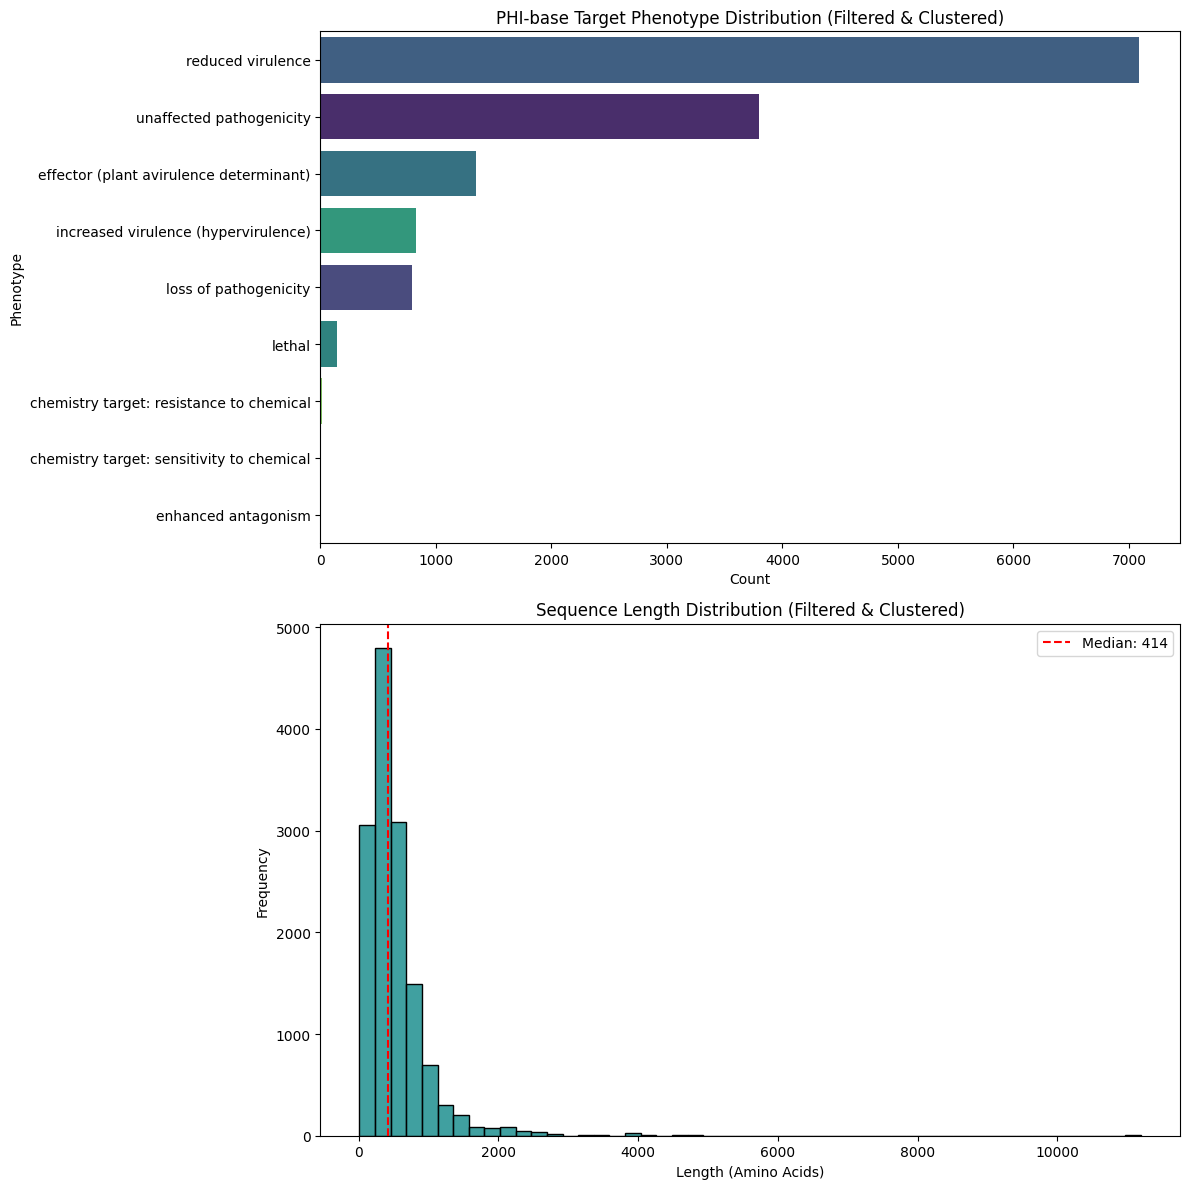

                                           count  min    max
Phenotype_of_mutant                                         
chemistry target: resistance to chemical      15  132   1315
chemistry target: sensitivity to chemical      6  132    869
effector (plant avirulence determinant)     1345   33   4034
enhanced antagonism                            4  519    557
increased virulence (hypervirulence)         829   22   4690
lethal                                       148   85   3880
loss of pathogenicity                        797   22   5218
reduced virulence                           7087   11  11197
unaffected pathogenicity                    3797   31   4841


In [9]:
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
order = df_raw['Phenotype_of_mutant'].value_counts().index
sns.countplot(
    data=df_raw,
    y='Phenotype_of_mutant',
    order=order,
    palette='viridis',
    hue='Phenotype_of_mutant',
    legend=False
)
plt.title('PHI-base Target Phenotype Distribution (Filtered & Clustered)')
plt.xlabel('Count')
plt.ylabel('Phenotype')

plt.subplot(2, 1, 2)
sns.histplot(df_raw['seq_length'], bins=50, color='teal')
plt.axvline(x=df_raw['seq_length'].median(), color='red', linestyle='--', label=f'Median: {df_raw["seq_length"].median():.0f}')
plt.title('Sequence Length Distribution (Filtered & Clustered)')
plt.xlabel('Length (Amino Acids)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

stats = df_raw.groupby(df_raw['Phenotype_of_mutant'].str.lower())['seq_length'].agg(['count', 'min', 'max'])
print(stats)

## Takeaways

PHI-base is phenotype-centric, not gene-centric. There are 9,973 unique genes, but they can be associated with multiple experiments, hosts, or mutant phenotypes.

# 3 Biological Quality Control

This section applies filters to ensure the sequences are suitable for the ESM-2 model.
- Remove rows with duplicate sequences:
  - If same gene, different phenotype (noisy labels), remove both rows
  - If same gene, same phenotype, different host, randomly keep 1 representative row (remove now rather than influencing MMseqs2 clustering later)
- Removing fragments and overly long outliers
- Checking for ambiguous residues

In [10]:
targets = [
    "reduced virulence",
    "unaffected pathogenicity",
    "effector (plant avirulence determinant)",
    "increased virulence (hypervirulence)",
    "loss of pathogenicity"
]

# 1. Generate the 5-phenotype dataset
df_raw['seq_length'] = df_raw['sequence'].apply(len)
df_viz = df_raw[df_raw['Phenotype_of_mutant'].str.lower().isin(targets)].copy()
print(f"Rows in 5-phenotype dataset: {len(df_viz)}")

# 2. Remove all rows for genes with conflicting phenotypes
overlap_counts = df_viz.groupby('PHI_MolConn_ID')['Phenotype_of_mutant'].nunique()
conflicting_genes = overlap_counts[overlap_counts > 1].index
conflicting_rows = df_viz['PHI_MolConn_ID'].isin(conflicting_genes)

print(f"Rows with conflicting phenotypes removed: {conflicting_rows.sum()}")
df_viz = df_viz[~conflicting_rows].copy()

# 3. Remove redundant rows (same phenotype, different host)
unique_genes = df_viz['PHI_MolConn_ID'].nunique()
redundant_rows = len(df_viz) - unique_genes

print(f"Redundant rows removed: {redundant_rows}")
df_viz = df_viz.sample(frac=1, random_state=config['splitting']['random_seed']).drop_duplicates(subset=['PHI_MolConn_ID'], keep='first')

# 4. Final cleaned dataset check
print(f"Cleaned dataset rows: {len(df_viz)}")
is_unique = len(df_viz) == df_viz['PHI_MolConn_ID'].nunique()
print(f"All genes unique: {is_unique}")

Rows in 5-phenotype dataset: 13855
Rows with conflicting phenotypes removed: 2917
Redundant rows removed: 3249
Cleaned dataset rows: 7689
All genes unique: True


## Defence of filtering thresholds

**Lower Threshold (50 AA):**

PHI-base relies on literature curation of experimental evidence, so these short sequences are real secreted peptides or effectors, not spurious ORFs. However, very short peptides often lack a stable tertiary structure or interact in different ways to larger globular proteins, which means they can behave differently in the model's embedding space.

**Upper Threshold (1500 AA):**

ESM0-2 uses Rotary Position Embedding (RoPE), which allows it to theoretically extrapolate beyond its 1,024 token training context window. The 1,500 AA cutoff is primarily a hardware constraint, since the self-attention mechanism scales quadratically $O(N^2)$ with sequence length. This cutoff also helps exclude multi-domain fusions where the effector-specific signal might be diluted across thousands of unrelated residues.

**Ambiguity (0.0):**

ESM-2 uses self-attention to infer structural and evolutionary relationships between individual residues. Unknown tokens introduce significant noise and degrade the contextual embeddings for the valid surrounding regions.



In [11]:
df = df_viz.copy()
counts = [len(df)]
print(f"Initial count: {len(df)}")

# 5. Minimum Length Filtering
min_len = config['filtering']['min_seq_length']
df = df[df['seq_length'] >= min_len]
counts.append(len(df))
print(f"Removed < {min_len}: {counts[0] - counts[1]}")

# 6. Maximum Length Filtering
max_len = config['filtering']['max_seq_length']
df = df[df['seq_length'] <= max_len]
counts.append(len(df))
print(f"Removed > {max_len}: {counts[1] - counts[2]}")

# 7. Ambiguous Residue Filtering
ambiguity_threshold = config['filtering']['ambiguity']
df = df[df['sequence'].str.count('X') / df['seq_length'] <= ambiguity_threshold]
counts.append(len(df))
print(f"Removed (ambiguous): {counts[2] - counts[3]}")

# 8. Final Label Mapping
mapping = {k.lower(): v for k, v in config['target_mapping'].items()}
df['label'] = df['Phenotype_of_mutant'].str.lower().map(mapping)

print(f"Final remaining: {len(df)}")

Initial count: 7689
Removed < 50: 26
Removed > 1500: 261
Removed (ambiguous): 19
Final remaining: 7383


# 4 Redundancy Reduction with MMseqs2 Clustering

This section uses MMseqs2 to reduce dataset redundancy by grouping highly similar protein sequences into clusters. Retaining only a single representative sequence (centroid) from each cluster prevents data leakage between the training and hold-out test sets. This ensures the model learns generalisable biological features rather than memorising near-identical sequences.

## Defence of filtering thresholds

**Identity (90%):**

90% sequence identity is a standard method used to prevent data leakage, similar to the UniRef90 database. It collapses minor strain-level variations, orthologs from very closely related species, or sequencing artifacts of the exact same protein into a single representitive sequence.
*Why is this an optimal cutoff?*

In [12]:
processed_dir = config['paths']['processed_dir']

absolute_path = os.path.abspath(processed_dir)
print(f"Saving files to absolute path: {absolute_path}")
print(f"Initial Count: {len(df)}")

os.makedirs(processed_dir, exist_ok=True)

# Write filtered sequences to FASTA file.
fasta_in = os.path.join(processed_dir, "temp_input.fasta")
with open(fasta_in, "w") as f:
    for _, row in df.iterrows():
        f.write(f">{row['PHI_MolConn_ID']}\n{row['sequence']}\n")

# Run MMseqs2 easy-cluster in local storage (Google Drive FUSE doesn't support mmap)
local_work = "/content/mmseqs_work"
os.makedirs(local_work, exist_ok=True)

local_fasta = os.path.join(local_work, "temp_input.fasta")
shutil.copy(fasta_in, local_fasta)

local_prefix = os.path.join(local_work, "cluster_res")
local_tmp = os.path.join(local_work, "tmp_mmseqs")
os.makedirs(local_tmp, exist_ok=True)

identity_threshold = config['clustering']['identity_threshold']
out_prefix = os.path.join(processed_dir, "cluster_res")

cmd = [
    "mmseqs", "easy-cluster",
    local_fasta, local_prefix, local_tmp,
    "--min-seq-id", str(identity_threshold),
    "-c", "0.8",
    "--cov-mode", "1"
]

subprocess.run(cmd, check=True)

# Copy results back to Drive
for suffix in ["_cluster.tsv", "_rep_seq.fasta", "_all_seqs.fasta"]:
    src = local_prefix + suffix
    if os.path.exists(src):
        shutil.copy(src, out_prefix + suffix)

# Filter dataframe to keep only cluster centroids
tsv_out = f"{out_prefix}_cluster.tsv"
clusters = pd.read_csv(tsv_out, sep='\t', header=None, names=['representative', 'member'])

centroids = clusters['representative'].unique()
df = df[df['PHI_MolConn_ID'].isin(centroids)].copy()

print(f"Sequences remaining after clustering: {len(df)}")

# Clean up
for ext in ['_all_seqs.fasta', '_cluster.tsv', '_rep_seq.fasta']:
    for prefix in [out_prefix, local_prefix]:
        file_path = f"{prefix}{ext}"
        if os.path.exists(file_path):
            os.remove(file_path)
if os.path.exists(fasta_in):
    os.remove(fasta_in)
shutil.rmtree(local_work, ignore_errors=True)

Saving files to absolute path: /content/drive/MyDrive/esm-phi-effector/data/processed
Initial Count: 7383
Sequences remaining after clustering: 6889


# 4.2 Cleaned Dataset Visualisation

This section visualises the cleaned dataset.

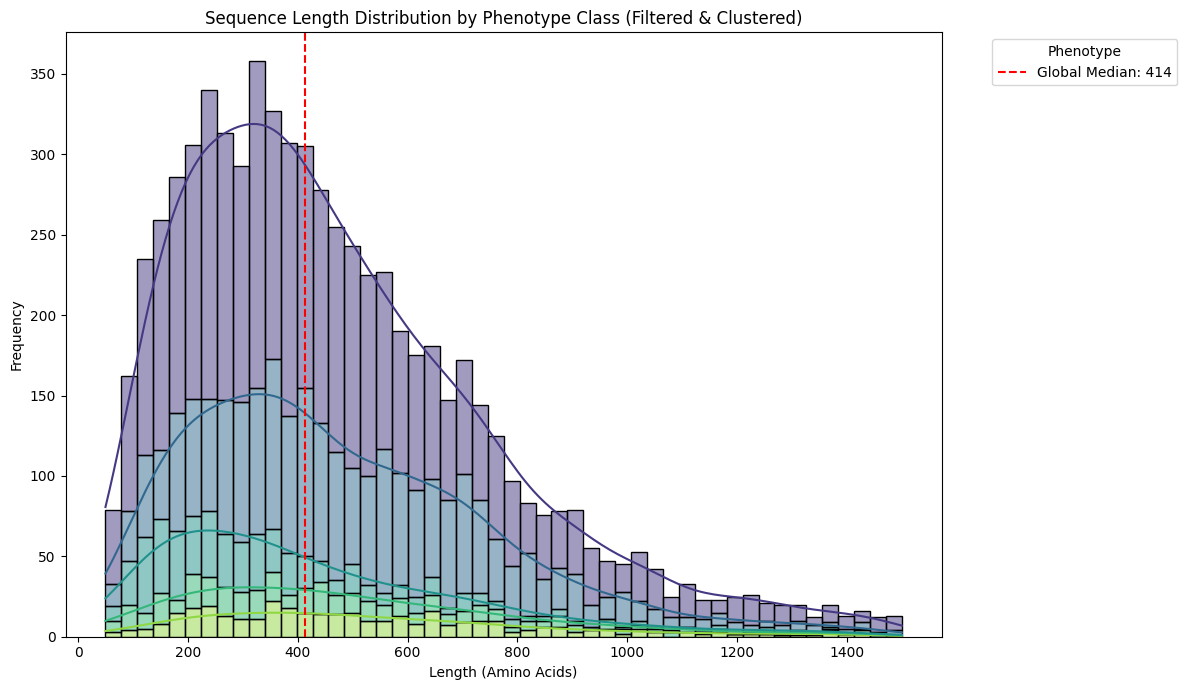

                                         count  min   max
Phenotype_of_mutant                                      
reduced virulence                         3552   50  1500
unaffected pathogenicity                  2029   53  1499
effector (plant avirulence determinant)    571   54  1440
increased virulence (hypervirulence)       373   55  1498
loss of pathogenicity                      364   65  1425


In [13]:
# Stacked histogram of sequence lengths by phenotype
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df,
    x='seq_length',
    hue='Phenotype_of_mutant',
    bins=50,
    kde=True,
    multiple='stack',
    palette='viridis'
)
plt.axvline(
    x=df['seq_length'].median(),
    color='red',
    linestyle='--',
    label=f'Global Median: {df["seq_length"].median():.0f}'
)
plt.title('Sequence Length Distribution by Phenotype Class (Filtered & Clustered)')
plt.xlabel('Length (Amino Acids)')
plt.ylabel('Frequency')
plt.legend(title='Phenotype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary statistics ordered by count (high to low)
stats = (
    df.groupby(df['Phenotype_of_mutant'].str.lower())['seq_length']
    .agg(['count', 'min', 'max'])
    .sort_values(by='count', ascending=False)
)
print(stats)

## Takeaways

- The classes are imbalanced. "reduced virulence" is almost twice as large as the second largest class "unaffected pathogenicity".
- Whilst the majority of sequences are of lengths below 2,000, some sequences are as long as 11,000 residues. All five classes have very small (below 40 residues) and very large (above 4,000 residues) sequences.

## Imbalanced class size strategy

The classes are highly imbalanced. "reduced virulence" accounts for 51.5% of the dataset, and "loss of pathogenicity" accounts for only 5.3% of the dataset.

**Plan A: No change**

To begin with, I will not implement any resampling for the following reasons:
1. Although accuracy can be inflated if the model simply predicts the majority class every time, I can prioritise precision-recall curves and F1-scores, which are more robust for assessing model quality on minority classes.
2. Keeping the natural data distribution helps the model learn that certain phenotypes are rarer biological events.
3. ESM-2 is a powerful transformer, and with proper regularisation it may be able to learn distinct features for the smaller classes without needing artificial balance.

**Plan B: Weighted Loss Functions**

If the model completely fails to predict the smaller classes during the initial validation, I will implement weighted cross-entropy loss to penalise the model more for misclassifying the rarer classes than the more common ones.

**Plan C: Downsampling**

If this also does not work, I will first try to balance the class sizes more by reducing the "reduced virulence" class size to that of "unaffected pathogenicity". This plan will also be necessary if GPU resources are limiting. However, it risks losing valuable variability information.

**Plan D: Upsampling:**

Finally, I may attempt to upsample the smallest classes by duplicating or synthesizing (e.g. via SMOTE) the data.

# 5 Data splits

This section involves splitting the data into training, validation, and hold-out test sets

In [14]:
label_col = "Phenotype_of_mutant"
test_size = config['splitting']['test_size']
val_size = config['splitting']['val_size']
seed = config['splitting']['random_seed']

# Stratified split: train+val / test
df_trainval, df_test = train_test_split(
    df, test_size=test_size, random_state=seed,
    stratify=df[label_col]
)

# Split train+val into train / val
# val_size is proportion of *total*, so adjust for the remaining data
val_frac = val_size / (1 - test_size)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_frac, random_state=seed,
    stratify=df_trainval[label_col]
)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df[label_col])
df_train['label'] = le.transform(df_train[label_col])
df_val['label'] = le.transform(df_val[label_col])
df_test['label'] = le.transform(df_test[label_col])

print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Train: 4822, Val: 689, Test: 1378
Classes: {'effector (plant avirulence determinant)': np.int64(0), 'increased virulence (hypervirulence)': np.int64(1), 'loss of pathogenicity': np.int64(2), 'reduced virulence': np.int64(3), 'unaffected pathogenicity': np.int64(4)}


# 6 Tokenization

This step converts biological sequences into numerical representations that the transformer architecture can process. Using the pre-trained ESM-2 tokenizer ensures each amino acid is mapped to the specific integer ID established during the model's original training, while padding and truncation ensure uniform tensor shapes required for efficient hardware acceleration.

## Strategies for handling ESM-2 sequences longer than the 1,022 AA limit (1,024 including CLS and EOS)

**Strategy 1: Truncation**

The default behaviour in the ESM extraction scripts. Lossy and may lose information meaningful for prediction.

**Strategy 2: Sliding Window with Averaging**

Split the sequence into non-overlapping chunks that fit within the context window. Extract embeddings for each chunk independently, then aggregate. Oliveira et al., 2025 (https://doi.org/10.5753/bsb.2024.244804). Normally recommended to process with length-weighted averaging.

Residues near chunk boundaries lose long-range context - overlapping windows can mitigate this - process overlapping chunks and average the embeddings for residues covered by multiple windows.

**Strategy 3: Domain-Level Extraction**

Use functional annotations (e.g. Pfam domains) to extract biologically meaningful sub-regions that fit within the context window (e.g. think NLR NB-ARC domain).

**Strategy 4: Architectural Modifications**

Oliveria et al., 2025 also adapted ESM-2 architectures using Longformer-style local attention to double the context window. These models are available on HuggingFace. Long versions were not available for the largest ESM-2 variants (T36 and T48).

**Strategy 5: Random Cropping**

During ESM-2 pretraining, the original approach used random cropping for sequences exceeding the context window. This could also be applied during fine tuning - each epoch samples a different random crop of long sequences, so the model eventually sees different parts of the protein across training steps. This provides a form of data augmentation.

## Configuration choices

**ESM-2 Model ("facebook/esm2_t30_150M_UR50D"):**

The t30 version is a 30-layer transformer with 150 million parameters. This is a middle-ground in terms of size, which provides high-quality biological representations while remaining computationally manageable. UR50D indicates the model was trained on the UniRef50 database.

**Max token length (1,024):**

This defines the fixed size for all input vectors. In JAX, the XLA (accelerated linear algebra) compiler requires static array shapes to optimise performance. By padding shorter sequences and truncating longer ones to 1,024 tokens, it avoids constantly recompiling the execution graph and ensure the model can handle the maximum context window supported by ESM-2.

##

## Generate frozen embeddings

In [15]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = config['tokenization']['esm_model']
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).eval().to("cuda")

MAX_LEN = 1022  # 1024 - CLS - EOS

def get_embeddings(sequences, method="truncate", overlap=0, batch_size=8):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i:i + batch_size]

            for seq in batch_seqs:
                if len(seq) <= MAX_LEN or method == "truncate":
                    # Truncation: short seqs pass through, long seqs get clipped
                    inputs = tokenizer(seq, return_tensors="pt", truncation=True,
                                       max_length=MAX_LEN + 2).to("cuda")
                    output = model(**inputs).last_hidden_state
                    emb = output[0, 1:-1].mean(dim=0)

                elif method == "sliding":
                    # Non-overlapping sliding window
                    chunks = [seq[j:j + MAX_LEN] for j in range(0, len(seq), MAX_LEN)]
                    chunk_embs, chunk_lens = [], []
                    for chunk in chunks:
                        inputs = tokenizer(chunk, return_tensors="pt", truncation=True,
                                           max_length=MAX_LEN + 2).to("cuda")
                        output = model(**inputs).last_hidden_state
                        chunk_embs.append(output[0, 1:-1].mean(dim=0))
                        chunk_lens.append(len(chunk))
                    weights = torch.tensor(chunk_lens, dtype=torch.float, device="cuda")
                    weights /= weights.sum()
                    emb = (torch.stack(chunk_embs) * weights.unsqueeze(1)).sum(dim=0)

                elif method == "sliding_overlap":
                    # Overlapping sliding window
                    step = MAX_LEN - overlap
                    chunks = [seq[j:j + MAX_LEN] for j in range(0, len(seq), step)]
                    chunk_embs, chunk_lens = [], []
                    for chunk in chunks:
                        inputs = tokenizer(chunk, return_tensors="pt", truncation=True,
                                           max_length=MAX_LEN + 2).to("cuda")
                        output = model(**inputs).last_hidden_state
                        chunk_embs.append(output[0, 1:-1].mean(dim=0))
                        chunk_lens.append(len(chunk))
                    weights = torch.tensor(chunk_lens, dtype=torch.float, device="cuda")
                    weights /= weights.sum()
                    emb = (torch.stack(chunk_embs) * weights.unsqueeze(1)).sum(dim=0)

                all_embeddings.append(emb.cpu())

            if (i // batch_size) % 50 == 0:
                print(f"  Processed {min(i + batch_size, len(sequences))}/{len(sequences)}")

    return torch.stack(all_embeddings)

# Generate and save embeddings for all three methods
emb_base_dir = os.path.join(config['paths']['splits_dir'], "frozen_embeddings")

methods = {
    "truncate":        {"method": "truncate", "overlap": 0},
    "sliding":         {"method": "sliding", "overlap": 0},
    "sliding_overlap": {"method": "sliding_overlap", "overlap": 200},
}

for name, params in methods.items():
    print(f"\n{'='*50}")
    print(f"Generating embeddings: {name}")
    print(f"{'='*50}")

    save_dir = os.path.join(emb_base_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    print("  Train...")
    X_train = get_embeddings(df_train['sequence'].tolist(), **params)
    print("  Val...")
    X_val = get_embeddings(df_val['sequence'].tolist(), **params)
    print("  Test...")
    X_test = get_embeddings(df_test['sequence'].tolist(), **params)

    torch.save({
        'X_train': X_train, 'y_train': torch.tensor(df_train['label'].values),
        'X_val': X_val, 'y_val': torch.tensor(df_val['label'].values),
        'X_test': X_test, 'y_test': torch.tensor(df_test['label'].values),
        'label_encoder': le,
        'method': name,
        'overlap': params['overlap'],
        'model': model_name,
    }, os.path.join(save_dir, f"embeddings_{name}.pt"))

    print(f"  Saved to {save_dir}/embeddings_{name}.pt | Shape: {X_train.shape}")

print(f"\nAll embeddings saved to: {emb_base_dir}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Generating embeddings: truncate
  Train...
  Processed 8/4822
  Processed 408/4822
  Processed 808/4822
  Processed 1208/4822
  Processed 1608/4822
  Processed 2008/4822
  Processed 2408/4822
  Processed 2808/4822
  Processed 3208/4822
  Processed 3608/4822
  Processed 4008/4822
  Processed 4408/4822
  Processed 4808/4822
  Val...
  Processed 8/689
  Processed 408/689
  Test...
  Processed 8/1378
  Processed 408/1378
  Processed 808/1378
  Processed 1208/1378
  Saved to data/splits/frozen_embeddings/truncate/embeddings_truncate.pt | Shape: torch.Size([4822, 640])

Generating embeddings: sliding
  Train...
  Processed 8/4822
  Processed 408/4822
  Processed 808/4822
  Processed 1208/4822
  Processed 1608/4822
  Processed 2008/4822
  Processed 2408/4822
  Processed 2808/4822
  Processed 3208/4822
  Processed 3608/4822
  Processed 4008/4822
  Processed 4408/4822
  Processed 4808/4822
  Val...
  Processed 8/689
  Processed 408/689
  Test...
  Processed 8/1378
  Processed 408/1378
  Proces

## Fine-tuning dataset

In [16]:
from torch.utils.data import Dataset

class ProteinDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=1022):
        self.sequences = df['sequence'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        if len(seq) <= self.max_len:
            inputs = self.tokenizer(seq, truncation=True, max_length=self.max_len + 2,
                                    padding="max_length", return_tensors="pt")
        else:
            # Random crop for augmentation during fine-tuning
            start = torch.randint(0, len(seq) - self.max_len + 1, (1,)).item()
            crop = seq[start:start + self.max_len]
            inputs = self.tokenizer(crop, truncation=True, max_length=self.max_len + 2,
                                    padding="max_length", return_tensors="pt")

        return {k: v.squeeze(0) for k, v in inputs.items()}, self.labels[idx]

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = ProteinDataset(df_train, tokenizer, max_len=MAX_LEN)
val_dataset = ProteinDataset(df_val, tokenizer, max_len=MAX_LEN)
test_dataset = ProteinDataset(df_test, tokenizer, max_len=MAX_LEN)

# Save datasets
ft_dir = os.path.join(config['paths']['splits_dir'], "fine_tuning_dataset")
os.makedirs(ft_dir, exist_ok=True)

for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    torch.save({
        'sequences': split_df['sequence'].tolist(),
        'labels': split_df['label'].tolist(),
        'ids': split_df['PHI_MolConn_ID'].tolist(),
        'phenotypes': split_df[label_col].tolist(),
        'label_encoder': le,
        'model': model_name,
    }, os.path.join(ft_dir, f"{split_name}.pt"))

print(f"Fine-tuning datasets saved to: {ft_dir}")
print(f"  train.pt: {len(train_dataset)} samples")
print(f"  val.pt:   {len(val_dataset)} samples")
print(f"  test.pt:  {len(test_dataset)} samples")

# Sanity check
inputs, label = train_dataset[0]
print(f"\nSanity check - Input IDs shape: {inputs['input_ids'].shape}, Label: {label}")

Fine-tuning datasets saved to: data/splits/fine_tuning_dataset
  train.pt: 4822 samples
  val.pt:   689 samples
  test.pt:  1378 samples

Sanity check - Input IDs shape: torch.Size([1024]), Label: 4
